# Intent Discovery — AmazonHelp

NMF topic modeling to discover customer support intents from Amazon tweets.

**Steps:**
1. Load cleaned data (already filtered/denoised by notebook 01 — English-verified, numbers/dates removed, `text`)
2. TF-IDF vectorization
3. NMF topic modeling with auto-k
4. Label topics manually
5. Assign intent labels & confidence
6. Save labeled dataset


## 1. Install Dependencies


In [126]:
!pip install scikit-learn matplotlib seaborn kagglehub -q


## 2. Imports


In [127]:
import pandas as pd
import numpy as np
import os
import json
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF

import matplotlib.pyplot as plt
import seaborn as sns

print('All imports successful')


All imports successful


## 3. Load Processed Data


In [128]:
PROCESSED_PATH = '/kaggle/input/data-preprocessed/data_preprocessed.csv'
LOCAL_PATH = '../data/processed/data_preprocessed.csv'

if os.path.exists(PROCESSED_PATH):
    DATA_PATH = PROCESSED_PATH
elif os.path.exists(LOCAL_PATH):
    DATA_PATH = LOCAL_PATH
else:
    DATA_PATH = '/kaggle/working/data_preprocessed.csv'

df = pd.read_csv(DATA_PATH)
print(f'Loaded: {len(df)} rows from {DATA_PATH}')
df.head()


Loaded: 31972 rows from /kaggle/working/data_preprocessed.csv


,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id
0,173478,156612,True,Fri Nov 24 22:57:58 +0000 2017,yes i have i ask it to resend the code a few time,173477,173479.0
1,341491,197580,True,Sat Oct 28 07:07:02 +0000 2017,what type of communication r u do with me day ...,"341490,341492",341493.0
2,870162,326613,True,Fri Oct 13 16:13:49 +0000 2017,will u let people know what action i have take...,"870166,870167",870160.0
3,2576953,254045,True,Sun Dec 03 04:02:46 +0000 2017,and when i try to contact you i get a message ...,NaN,2576951.0
4,407048,212017,True,Tue Oct 10 07:23:17 +0000 2017,give i have already spend several hour sort yo...,NaN,407045.0


## 4. TF-IDF Vectorization


In [129]:
# Topics are discovered by discriminative words - generic/stop words only muddy them.
# - stop_words='english': remove 'about', 'the', 'be' etc that appear across all topics
# - max_df=0.5: drop terms in >50% of docs (near-universal terms don't separate topics)
# - ngram_range=(1,1): unigrams keep short tweets clean; bigrams add noise

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 1),
    min_df=3,
    max_df=0.5,
    stop_words='english',
    lowercase=True
)

tfidf_matrix = tfidf.fit_transform(df['text'])
feature_names = tfidf.get_feature_names_out()

print(f'TF-IDF matrix: {tfidf_matrix.shape}')
print(f'Vocabulary size: {len(feature_names)}')
print(f'Top 30 features: {list(feature_names[:30])}')


TF-IDF matrix: (31972, 4684)
Vocabulary size: 4684
Top 30 features: ['100rs', '1080p', '10days', '10k', '12hours', '12hrs', '15days', '15mins', '1click', '1creditcard', '1day', '1hr', '1k', '1month', '1n', '1x', '20days', '24h', '24hr', '24hrs', '2day', '2days', '2fa', '2hrs', '2k', '2k18', '2weeks', '2x', '30k', '30mins']


## 5. NMF Topic Modeling — Find Optimal k


In [130]:
def compute_coherence(model, tfidf_matrix, feature_names, top_n=10):
    from sklearn.metrics.pairwise import cosine_similarity
    scores = []
    for topic_idx in range(model.n_components):
        topic = model.components_[topic_idx]
        top_indices = topic.argsort()[:-top_n - 1:-1]
        top_words = [feature_names[i] for i in top_indices]
        word_vectors = []
        for word in top_words:
            if word in feature_names:
                idx = list(feature_names).index(word)
                word_vectors.append(tfidf_matrix[:, idx].toarray().flatten())
        if len(word_vectors) > 1:
            sim_matrix = cosine_similarity(word_vectors)
            pairs = [sim_matrix[j][k] for j in range(len(word_vectors)) for k in range(j+1, len(word_vectors))]
            scores.append(np.mean(pairs) if pairs else 0)
        else:
            scores.append(0)
    return np.mean(scores)

# Try different k values
k_range = range(5, 16)
results = []

for k in k_range:
    nmf = NMF(
        n_components=k,
        random_state=42,
        max_iter=500,
        init='nndsvda'
    )
    W = nmf.fit_transform(tfidf_matrix)
    coherence = compute_coherence(nmf, tfidf_matrix, feature_names)
    results.append({'k': k, 'coherence': coherence})
    print(f'k={k:2d}  coherence={coherence:.4f}')

results_df = pd.DataFrame(results)
BEST_K = int(results_df.loc[results_df['coherence'].idxmax(), 'k'])
print(f'\nBest k: {BEST_K}')




k= 5  coherence=0.0700
k= 6  coherence=0.0638
k= 7  coherence=0.0637
k= 8  coherence=0.0641
k= 9  coherence=0.0592
k=10  coherence=0.0569
k=11  coherence=0.0569
k=12  coherence=0.0557
k=13  coherence=0.0545
k=14  coherence=0.0515
k=15  coherence=0.0499

Best k: 5


## 6. Plot Coherence vs k


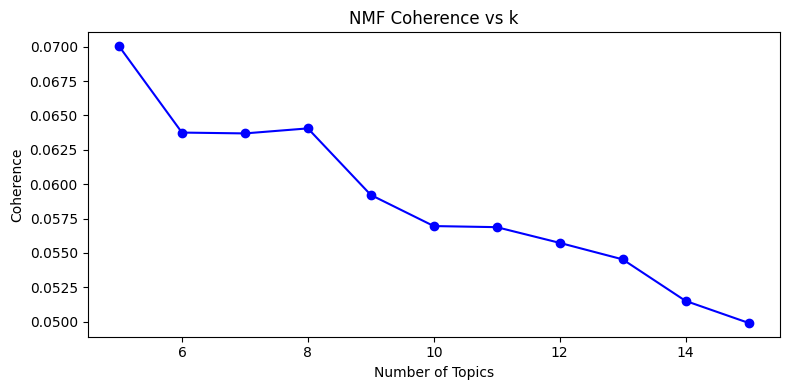

In [131]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(results_df['k'], results_df['coherence'], 'b-o')
ax.set_xlabel('Number of Topics')
ax.set_ylabel('Coherence')
ax.set_title('NMF Coherence vs k')
plt.tight_layout()
plt.show()

## 7. Fit Final Model & Show Topics


In [132]:
# Fit final NMF model
nmf_final = NMF(
    n_components=BEST_K,
    random_state=42,
    max_iter=500,
    init='nndsvda'
)

W = nmf_final.fit_transform(tfidf_matrix)

# Get top words per topic
feature_names = tfidf.get_feature_names_out()
topics = []
for i in range(BEST_K):
    topic = nmf_final.components_[i]
    top_words = [feature_names[j] for j in topic.argsort()[:-11:-1]]
    topics.append(top_words)

print(f'\nDiscovered {BEST_K} topics:\n')
for i, topic_words in enumerate(topics):
    print(f'Topic {i}: {" | ".join(topic_words[:10])}')




Discovered 5 topics:

Topic 0: delivery | day | say | deliver | today | prime | package | arrive | date | wait
Topic 1: amazon | customer | time | service | contact | refund | product | want | issue | care
Topic 2: order | cancel | place | item | receive | ship | refund | number | return | hi
Topic 3: email | send | receive | reply | message | account | direct | mail | check | link
Topic 4: help | thanks | thank | just | response | resolve | try | need | issue | ok


## 8. Label Each Topic


In [133]:
# Show sample tweets per topic for labeling — USE text to avoid time patterns
for i in range(BEST_K):
    print(f'\n{"="*60}')
    print(f'TOPIC {i}: {" | ".join(topics[i][:8])}')
    print(f'{"="*60}')
    top_indices = W[:, i].argsort()[-5:][::-1]
    for idx in top_indices:
        # USE text to avoid time patterns (4pm, 5pm, etc.)
        text = str(df.iloc[idx]['text'])[:150]
        print(f'  {text}')
    print()



TOPIC 0: delivery | day | say | deliver | today | prime | package | arrive
  it say today but that be not next day delivery be it amazon prime be next day and you get it next day
  last update due for delivery on the do not arrive still say due today which it have be say for day
  it say it have be out for delivery since today
  out for delivery a it have be for day
  how be this next day delivery


TOPIC 1: amazon | customer | time | service | contact | refund | product | want
  amazon it be not you it be nationwide
  it be from amazon
  it be either someone at amazon or at do
  amazon be anyone there
  how do we contact amazon customer service a product that i receive which be fulfil by amazon be the wrong product


TOPIC 2: order | cancel | place | item | receive | ship | refund | number
  what you have do with the order
  these be my order detail
  still nothing order be
  order from goat goat goat
  please see these two order


TOPIC 3: email | send | receive | reply | message | 

## 9. Label Each Topic Manually


In [134]:
TOPIC_LABELS = {
    0: 'delivery_issue',
    1: 'customer_service',
    2: 'order_status',
    3: 'email_contact',
    4: 'appreciation',
}


## 10. Assign Intent Labels


In [135]:
# Assign dominant topic to each tweet
df['topic_id'] = W.argmax(axis=1)
df['topic_confidence'] = W.max(axis=1)
df['intent'] = df['topic_id'].map(TOPIC_LABELS)

CONFIDENCE_THRESHOLD = float(df['topic_confidence'].quantile(0.25))
df['low_confidence'] = df['topic_confidence'] < CONFIDENCE_THRESHOLD

print(f'Assigned intents to {len(df)} tweets')
print(f"Low confidence: {df['low_confidence'].sum()} ({df['low_confidence'].mean()*100:.1f}%)")
print(f'\nIntent distribution:')
print(df['intent'].value_counts())



Assigned intents to 31972 tweets
Low confidence: 7993 (25.0%)

Intent distribution:
intent
customer_service    12675
delivery_issue       6682
email_contact        4511
order_status         4492
appreciation         3612
Name: count, dtype: int64


## 11. Save Labeled Dataset


In [136]:
# Save labeled dataset
output_path = '/kaggle/working/amazon_help_labeled.csv'
df[['tweet_id', 'author_id', 'text', 'created_at',
     'topic_id', 'topic_confidence', 'intent', 'low_confidence']].to_csv(output_path, index=False)
print(f'Saved: {output_path} ({len(df)} rows)')

# Save intent mapping
mapping_path = '/kaggle/working/intent_mapping.json'
mapping = {
    'topic_labels': {str(k): v for k, v in TOPIC_LABELS.items()},
    'top_words': {str(i): topics[i][:10] for i in range(BEST_K)},
    'config': {
        'best_k': BEST_K,
        'confidence_threshold': CONFIDENCE_THRESHOLD,
        'total_tweets': len(df)
    }
}
with open(mapping_path, 'w') as f:
    json.dump(mapping, f, indent=2)
print(f'Saved: {mapping_path}')


Saved: /kaggle/working/amazon_help_labeled.csv (31972 rows)
Saved: /kaggle/working/intent_mapping.json
